In [33]:
# Author: Ryan Reinaldo
# Course: Python for Analytics 
# Date: 02/06/2026 
# Purpose: Individual Assignment


## 1. Data Acquisition and Overview

### Source

The dataset is *Electric Vehicle Market and Pricing Dataset 2026*, published on Kaggle by Patel Ris:
[https://www.kaggle.com/datasets/patelris/electric-vehicle-market-and-pricing-dataset-2026](https://www.kaggle.com/datasets/patelris/electric-vehicle-market-and-pricing-dataset-2026)

### Contents

A single CSV file with 2,000 rows and 24 columns. The columns cover three broad domains:

- **Identification** — brand, model, year, variant, country of origin, market segment
- **Technical specifications** — price, battery capacity, range, charging speed, horsepower, torque, acceleration, top speed, weight, drive type, autopilot level, safety rating, seating, cargo, warranty
- **Commercial outcomes** — annual sales units, customer rating

### Research questions

This notebook will analyse four questions:

1. **What drives price?** Is it range, battery, brand, or something else?
2. **What drives customer satisfaction?** And is it the same thing as what drives price?
3. **What drives sales volume?** Which spec actually moves units?
4. **Are there geographic patterns** in cost-efficiency and value-for-money?


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', 24)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Load the dataset
df_ev_market = pd.read_csv('ev_market_2026.csv')

print(f"Shape: {df_ev_market.shape[0]:,} rows x {df_ev_market.shape[1]} columns")
df_ev_market.head()

Shape: 2,000 rows x 24 columns


,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,drive_type,seating_capacity,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,"104,880.80",118.70,400.00,234.50,3.04,195.00,"1,000.00",895.00,AWD,7,Truck,54.20,"2,015.00",4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,"48,217.41",58.80,219.00,148.10,5.77,159.00,381.00,360.00,FWD,5,SUV,69.00,"1,709.00",4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,"49,651.12",58.20,225.00,104.90,6.84,148.00,588.00,516.00,AWD,5,Van,77.00,"1,533.00",4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,"38,131.56",102.50,349.00,66.50,4.66,176.00,310.00,327.00,AWD,7,SUV,65.80,"1,935.00",4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,"144,079.87",93.90,314.00,298.50,5.64,165.00,"1,000.00",883.00,RWD,5,SUV,38.30,"2,229.00",4,2,US,Luxury,196401,3.83,4


In [35]:
# Quick column-level overview
df_ev_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

## 2. Data Cleaning and Preparation

### Approach

A clean dataset is not the same as a finished dataset. This section documents three things:

1. **Verification** — what was checked, and what was found
2. **Standardisation** — formatting inconsistencies that were corrected
3. **Preparation** — derived columns and decisions made about what to keep


### 2.1 Verification — missing values, duplicates, dtypes


In [36]:
# Check for missing values
missing = df_ev_market.isnull().sum()

print("Missing values per column:")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("None — every column is fully populated.")

Missing values per column:
None — every column is fully populated.


**Simulation of Data Cleansing**

Note: for the assignment purposes


In [37]:
# Build dirty_row using the same columns AND dtypes as df_ev_market
dirty_row = pd.DataFrame([{col: None for col in df_ev_market.columns}])
dirty_row = dirty_row.astype('float64', errors='ignore') # match dtypes (convert to float64) to solve the issue "Future Warning"
dirty_row['brand'] = 'Unknown'

df_ev_market = pd.concat([df_ev_market, dirty_row], ignore_index=True)

# Introduce a dummy column we don't need
df_ev_market['dummy_col'] = 'remove_me'

print("Shape before cleaning:", df_ev_market.shape)
print("\nDataFrame with dirty row and dummy column:")
print(df_ev_market[['brand', 'model', 'price_usd', 'range_miles', 'dummy_col']])  # preview a few columns

# Clean the data
df_ev_market = df_ev_market.dropna()                        # remove rows with any NaN
df_ev_market = df_ev_market.drop(columns=['dummy_col'])     # remove the dummy column

print("\nShape after cleaning:", df_ev_market.shape)
print("\nCleaned DataFrame preview:")
print(df_ev_market[['brand', 'model', 'price_usd', 'range_miles']])


Shape before cleaning: (2001, 25)

DataFrame with dirty row and dummy column:
             brand           model  price_usd  range_miles  dummy_col
0       Volkswagen        ID. Buzz 104,880.80       400.00  remove_me
1           Toyota  bZ Compact SUV  48,217.41       219.00  remove_me
2     GM/Chevrolet         Bolt EV  49,651.12       225.00  remove_me
3              Kia     Sportage EV  38,131.56       349.00  remove_me
4            Tesla         Model 3 144,079.87       314.00  remove_me
...            ...             ...        ...          ...        ...
1996        Toyota            bZ4X  66,816.55       367.00  remove_me
1997         Tesla         Model 3  49,281.26       325.00  remove_me
1998         Tesla         Model X 139,665.73       248.00  remove_me
1999           BYD             Qin  47,547.88       246.00  remove_me
2000       Unknown             NaN        NaN          NaN  remove_me

[2001 rows x 5 columns]

Shape after cleaning: (2000, 24)

Cleaned DataFrame prev

In [38]:
# Check for duplicate rows
n_duplicates = df_ev_market.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 0


In [39]:
# Check dtypes are sensible
print(df_ev_market.dtypes)

brand                     object
model                     object
year                     float64
variant                   object
price_usd                float64
battery_capacity_kwh     float64
range_miles              float64
charging_speed_kw        float64
acceleration_0_60_mph    float64
top_speed_mph            float64
horsepower               float64
torque_nm                float64
drive_type                object
seating_capacity         float64
body_type                 object
cargo_volume_cubic_ft    float64
weight_kg                float64
safety_rating            float64
autopilot_level          float64
country_of_origin         object
market_segment            object
annual_sales_units       float64
customer_rating          float64
warranty_years           float64
dtype: object


In [40]:
# Convert 5 integer columns back to the original 
int_cols = ['year', 'seating_capacity', 'safety_rating', 'autopilot_level', 'annual_sales_units', 'warranty_years']

df_ev_market[int_cols] = df_ev_market[int_cols].astype(int)

df_ev_market.info()   # verify

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  cargo_vol

**Verification result:** zero missing values, zero duplicate rows, all dtypes appropriate. The dataset is analysis-ready out of the box.

### 2.2 Standardisation — three inconsistencies to fix

Three categorical fields contain inconsistent formatting that needs standardising before grouping or visualisation. Each is documented below with the reason for the change.

In [41]:
# Inspect categorical fields for inconsistency
for col in ['country_of_origin', 'brand', 'market_segment']:
    print(f"{col}: {sorted(df_ev_market[col].unique())}")
    print()

country_of_origin: ['China', 'Germany', 'Japan', 'South Korea', 'Sweden', 'US']

brand: ['Audi', 'BMW', 'BYD', 'Fisker', 'Ford', 'GM/Chevrolet', 'Honda', 'Hyundai', 'Kia', 'Lucid', 'Mercedes', 'NIO', 'Polestar', 'Porsche', 'Rivian', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'Xiaomi']

market_segment: ['Budget', 'Luxury', 'Mid-range', 'Premium']



**Three inconsistencies spotted:**

1. `country_of_origin` — `'US'` is an abbreviation among full country names (Germany, Japan, South Korea, China, Sweden). Standardise to `'United States'`.
2. `brand` — `'GM/Chevrolet'` contains a slash inconsistent with the single-token naming used by every other brand. Standardise to `'GM'`.
3. `market_segment` — `'Mid-range'` uses a hyphen while the other three values (Budget, Premium, Luxury) are single unbroken words. Standardise to `'Midrange'`.


In [42]:
# Apply the three standardisations using .replace() with mapping dicts
df_ev_market['country_of_origin'] = df_ev_market['country_of_origin'].replace({'US': 'United States'})
df_ev_market['brand'] = df_ev_market['brand'].replace({'GM/Chevrolet': 'GM'})
df_ev_market['market_segment'] = df_ev_market['market_segment'].replace({'Mid-range': 'Midrange'})

# Verify the changes took effect
print("After standardisation:")
for col in ['country_of_origin', 'brand', 'market_segment']:
    print(f"{col}: {sorted(df_ev_market[col].unique())}")
    print()

After standardisation:
country_of_origin: ['China', 'Germany', 'Japan', 'South Korea', 'Sweden', 'United States']

brand: ['Audi', 'BMW', 'BYD', 'Fisker', 'Ford', 'GM', 'Honda', 'Hyundai', 'Kia', 'Lucid', 'Mercedes', 'NIO', 'Polestar', 'Porsche', 'Rivian', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'Xiaomi']

market_segment: ['Budget', 'Luxury', 'Midrange', 'Premium']



### 2.3 Preparation — derived columns

Four new columns are derived from existing ones. Each answers a question the raw data cannot answer directly:

| Column | Formula | Purpose |
|---|---|---|
| `revenue_usd` | `price_usd × annual_sales_units` | Total commercial value per model — "who makes the most money" |
| `usd_per_mile_range` | `price_usd ÷ range_miles` | Value-for-money on the headline EV feature |
| `usd_per_kwh` | `price_usd ÷ battery_capacity_kwh` | Value-for-money on battery capacity |
| `age_of_model` | `2026 − year` | Age in years — cleaner for trend analysis than raw year labels |



In [43]:
# Create the four derived columns
df_ev_market['revenue_usd'] = df_ev_market['price_usd'] * df_ev_market['annual_sales_units']
df_ev_market['usd_per_mile_range'] = df_ev_market['price_usd'] / df_ev_market['range_miles']
df_ev_market['usd_per_kwh'] = df_ev_market['price_usd'] / df_ev_market['battery_capacity_kwh']
df_ev_market['age_of_model'] = 2026 - df_ev_market['year']

# Confirm the new shape
print(f"After adding derived columns: {df_ev_market.shape[0]:,} rows x {df_ev_market.shape[1]} columns")
print("\nPreview:")
df_ev_market[['brand', 'model', 'price_usd', 'range_miles',
    'revenue_usd', 'usd_per_mile_range', 'usd_per_kwh', 'age_of_model']].head()

After adding derived columns: 2,000 rows x 28 columns

Preview:


,brand,model,price_usd,range_miles,revenue_usd,usd_per_mile_range,usd_per_kwh,age_of_model
0,Volkswagen,ID. Buzz,"104,880.80",400.00,"21,205,009,905.60",262.20,883.58,3
1,Toyota,bZ Compact SUV,"48,217.41",219.00,"344,561,611.86",220.17,820.02,4
2,GM,Bolt EV,"49,651.12",225.00,"823,712,080.80",220.67,853.11,2
3,Kia,Sportage EV,"38,131.56",349.00,"4,850,372,563.56",109.26,372.02,2
4,Tesla,Model 3,"144,079.87",314.00,"28,297,430,547.87",458.85,"1,534.40",4


## 3. Exploratory Data Analysis

### 3.1 First and last rows

In [44]:
df_ev_market.head(3)

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,...,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years,revenue_usd,usd_per_mile_range,usd_per_kwh,age_of_model
0,Volkswagen,ID. Buzz,2023,Performance,"104,880.80",118.70,400.00,234.50,3.04,195.00,"1,000.00",895.00,...,"2,015.00",4,2,Germany,Luxury,202182,4.00,4,"21,205,009,905.60",262.20,883.58,3
1,Toyota,bZ Compact SUV,2022,Premium,"48,217.41",58.80,219.00,148.10,5.77,159.00,381.00,360.00,...,"1,709.00",4,0,Japan,Midrange,7146,3.56,3,"344,561,611.86",220.17,820.02,4
2,GM,Bolt EV,2024,Premium,"49,651.12",58.20,225.00,104.90,6.84,148.00,588.00,516.00,...,"1,533.00",4,1,United States,Midrange,16590,3.70,3,"823,712,080.80",220.67,853.11,2


In [45]:
df_ev_market.tail(3)

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,...,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years,revenue_usd,usd_per_mile_range,usd_per_kwh,age_of_model
1997,Tesla,Model 3,2025,Long Range,"49,281.26",90.60,325.00,325.60,5.55,167.00,351.00,324.00,...,"2,920.00",3,3,United States,Midrange,224804,4.10,6,"11,078,624,373.04",151.63,543.94,1
1998,Tesla,Model X,2026,Premium,"139,665.73",70.70,248.00,330.70,5.07,175.00,"1,000.00",875.00,...,"1,500.00",3,2,United States,Luxury,165373,3.66,4,"23,096,940,767.29",563.17,"1,975.47",0
1999,BYD,Qin,2025,Premium,"47,547.88",67.40,246.00,67.20,6.76,156.00,522.00,494.00,...,"1,512.00",4,0,China,Midrange,214113,3.41,4,"10,180,619,230.44",193.28,705.46,1


### 3.2 Summary statistics for numerical columns

In [46]:
df_ev_market.describe().round(2)

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years,revenue_usd,usd_per_mile_range,usd_per_kwh,age_of_model
count,"2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00"
mean,"2,024.03","78,873.91",74.66,261.83,155.21,5.63,164.88,665.74,601.31,5.75,46.11,"1,886.16",4.38,1.12,"129,653.59",3.57,4.58,"10,112,464,304.79",319.61,"1,119.14",1.97
std,1.41,"35,296.62",20.08,71.03,80.98,1.42,20.78,267.12,238.71,1.05,19.85,383.77,0.66,0.92,"105,775.15",0.27,1.22,"10,548,568,684.45",162.25,566.08,1.41
min,"2,020.00","16,394.33",40.00,150.00,50.00,2.50,118.00,150.00,200.00,2.00,15.00,"1,500.00",3.00,0.00,656.00,3.00,3.00,"25,314,411.06",63.49,227.91,0.00
25%,"2,023.00","52,325.92",58.48,204.00,90.98,4.62,148.00,442.75,391.75,5.00,28.18,"1,570.00",4.00,0.00,"44,296.50",3.38,4.00,"3,241,650,323.79",200.87,706.84,1.00
50%,"2,024.00","73,013.02",75.10,261.00,132.10,5.67,165.00,683.00,615.50,5.00,41.25,"1,740.50",4.00,1.00,"111,188.00",3.56,4.00,"6,589,243,396.25",287.28,"1,011.99",2.00
75%,"2,025.00","99,780.16",87.55,310.00,217.30,6.77,181.00,939.25,845.00,7.00,64.70,"2,149.50",5.00,2.00,"202,496.75",3.75,5.00,"13,605,482,534.68",407.11,"1,406.82",3.00
max,"2,026.00","269,775.20",119.90,447.00,349.90,8.00,200.00,"1,000.00",988.00,7.00,80.00,"3,000.00",5.00,3.00,"499,717.00",4.51,8.00,"77,561,373,501.36","1,212.98","4,722.06",6.00


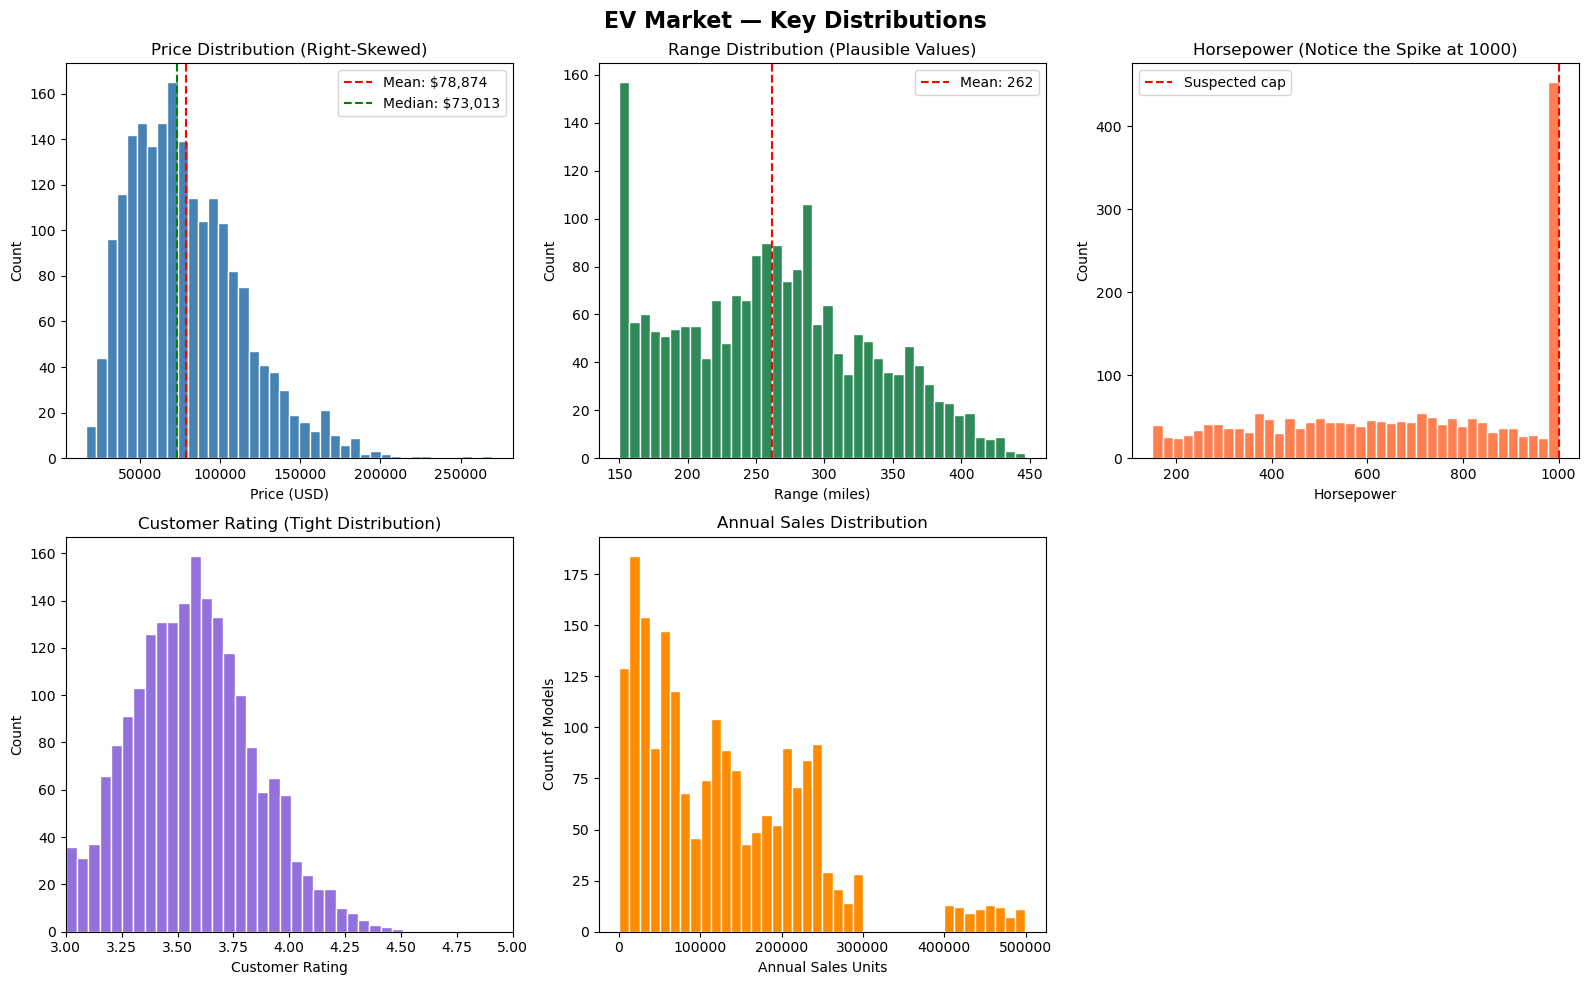

In [47]:
# Set up a 2x3 grid of subplots (5 charts + 1 empty)
figure_1, ax_1 = plt.subplots(2, 3, figsize=(16, 10))
figure_1.suptitle('EV Market — Key Distributions', fontsize=16, fontweight='bold')
ax_1 = ax_1.flatten()   # easier to index sequentially

# 1. price_usd
ax_1[0].hist(df_ev_market['price_usd'], bins=40, color='steelblue', edgecolor='white')
ax_1[0].axvline(df_ev_market['price_usd'].mean(), color='red', linestyle='--', label=f"Mean: ${df_ev_market['price_usd'].mean():,.0f}")
ax_1[0].axvline(df_ev_market['price_usd'].median(), color='green', linestyle='--', label=f"Median: ${df_ev_market['price_usd'].median():,.0f}")
ax_1[0].set_title('Price Distribution (Right-Skewed)')
ax_1[0].set_xlabel('Price (USD)')
ax_1[0].set_ylabel('Count')
ax_1[0].legend()

# 2. range_miles
ax_1[1].hist(df_ev_market['range_miles'], bins=40, color='seagreen', edgecolor='white')
ax_1[1].axvline(df_ev_market['range_miles'].mean(), color='red', linestyle='--', label=f"Mean: {df_ev_market['range_miles'].mean():,.0f}")
ax_1[1].set_title('Range Distribution (Plausible Values)')
ax_1[1].set_xlabel('Range (miles)')
ax_1[1].set_ylabel('Count')
ax_1[1].legend()

# 3. horsepower
ax_1[2].hist(df_ev_market['horsepower'], bins=40, color='coral', edgecolor='white')
ax_1[2].axvline(1000, color='red', linestyle='--', label='Suspected cap')
ax_1[2].set_title('Horsepower (Notice the Spike at 1000)')
ax_1[2].set_xlabel('Horsepower')
ax_1[2].set_ylabel('Count')
ax_1[2].legend()

# 4. customer_rating
ax_1[3].hist(df_ev_market['customer_rating'], bins=30, color='mediumpurple', edgecolor='white')
ax_1[3].set_title('Customer Rating (Tight Distribution)')
ax_1[3].set_xlabel('Customer Rating')
ax_1[3].set_ylabel('Count')
ax_1[3].set_xlim(3.0, 5.0)

# 5. annual_sales_units
ax_1[4].hist(df_ev_market['annual_sales_units'], bins=40, color='darkorange', edgecolor='white')
ax_1[4].set_title('Annual Sales Distribution')
ax_1[4].set_xlabel('Annual Sales Units')
ax_1[4].set_ylabel('Count of Models')

# Hide the unused 6th subplot
ax_1[5].axis('off')

plt.tight_layout()
plt.show()

**Things to notice in the summary statistics:**

- **`price_usd`** ranges from USD 16k to USD 270k. The mean (USD 75k) sits well above the median (USD 65k), confirming most cars cluster at lower price, but a small number of very expensive luxury EVs stretch the upper tail.
- **`range_miles`** sits between 150 and 447, with a mean of 262. No implausibly low or high values.
- **`horsepower`** maxes out at exactly 1000 across many rows, which is a dataset cap, not real-world variation.
- **`customer_rating`** has a very tight distribution (std 0.27 on a 3.0–5.0 scale). The differences between brands will be small but potentially meaningful.
- **`annual_sales_units`** spans 656 to ~500,000. It means some models barely sell, while others are mass-market hits.

### 3.3 Categorical breakdowns

In [48]:
# Use a loop to print value counts for each categorical column
cat_cols = ['brand', 'country_of_origin', 'market_segment',
            'drive_type', 'body_type', 'variant', 'year']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df_ev_market[col].value_counts())
    print()

--- brand ---
brand
Tesla         434
BYD           282
Volkswagen    194
Kia           166
Hyundai       152
BMW           150
GM            143
Ford          129
Mercedes       96
Audi           77
Toyota         41
Rivian         37
Fisker         25
NIO            23
Porsche        14
Volvo          12
Polestar        9
Xiaomi          8
Lucid           6
Honda           2
Name: count, dtype: int64

--- country_of_origin ---
country_of_origin
United States    774
Germany          531
South Korea      318
China            313
Japan             43
Sweden            21
Name: count, dtype: int64

--- market_segment ---
market_segment
Premium     712
Midrange    642
Luxury      495
Budget      151
Name: count, dtype: int64

--- drive_type ---
drive_type
AWD    754
RWD    678
FWD    568
Name: count, dtype: int64

--- body_type ---
body_type
Truck        427
SUV          364
Hatchback    324
Coupe        303
Sedan        301
Van          281
Name: count, dtype: int64

--- variant ---
vari

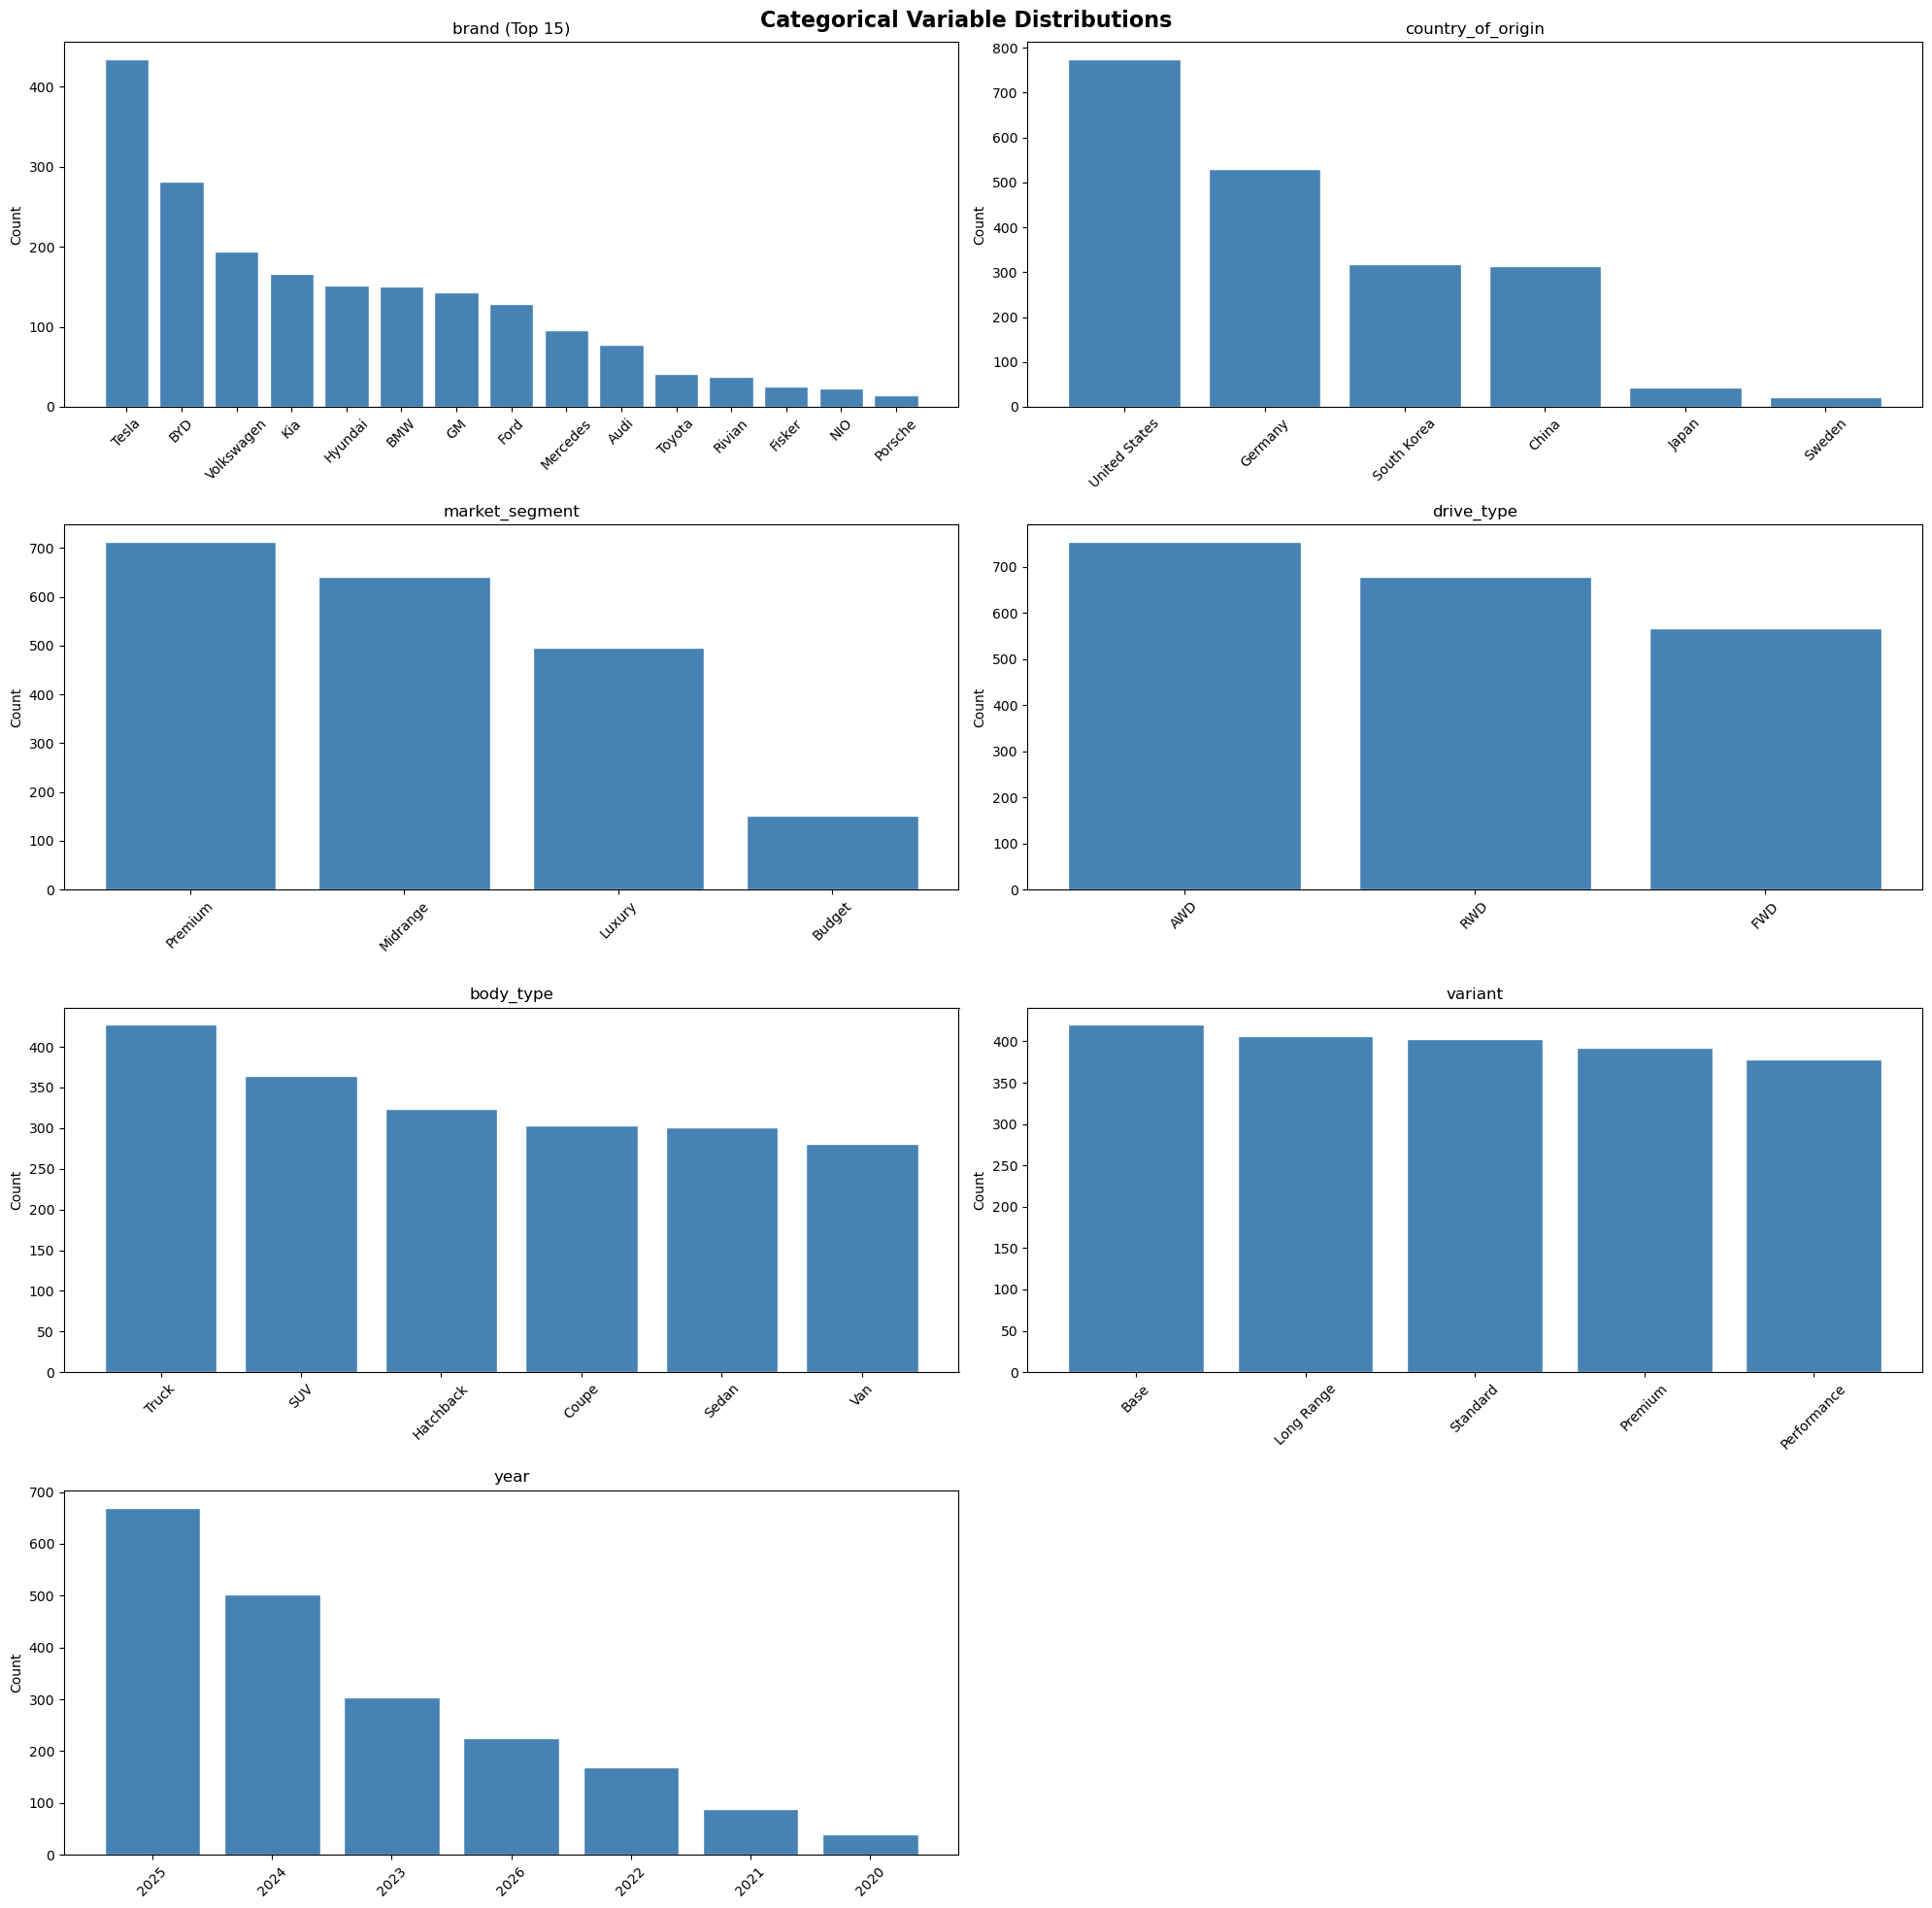

In [49]:
# 2x4 grid (7 charts + 1 empty)
figure_2, ax_2 = plt.subplots(4, 2, figsize=(20, 20))
figure_2.suptitle('Categorical Variable Distributions', fontsize=16, fontweight='bold')
ax_2 = ax_2.flatten()   # easier to index sequentially

for i, col in enumerate(cat_cols):
    counts = df_ev_market[col].value_counts() # counts how many times each unique value
    
    # If the category has too many values (like 'brand'), show only the top 15
    if len(counts) > 15:
        counts = counts.head(15)
        title_suffix = ' (Top 15)'
    else:
        title_suffix = ''
    
    ax_2[i].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
    ax_2[i].set_title(f'{col}{title_suffix}')
    ax_2[i].set_ylabel('Count')
    ax_2[i].tick_params(axis='x', rotation=45)

# Hide the unused 8th subplot
ax_2[7].axis('off')

plt.tight_layout()
plt.show()

**Observations:**

- Tesla is over-represented (about 22% of rows).
- The United States dominates country_of_origin (about 39%)
- Premium is the largest market segment (about 36%) and Budget the smallest (about 8%).
- 2024 and 2025 are the dominant model years (about 59% combined). 2026 is partial (about 11%).

## 4. Visualisation

Six charts, each chosen because it illuminates a specific question. The chart types vary deliberately: horizontal bar, scatter, heatmap, vertical bar with colour grouping, bubble chart, and scatter with overlaid trend line.


### Chart 1 — Top 10 brands by total revenue

A horizontal bar chart works better than vertical here because brand names read more naturally on the left. Total revenue (price x sales) tells a more complete commercial story than either price or units alone.


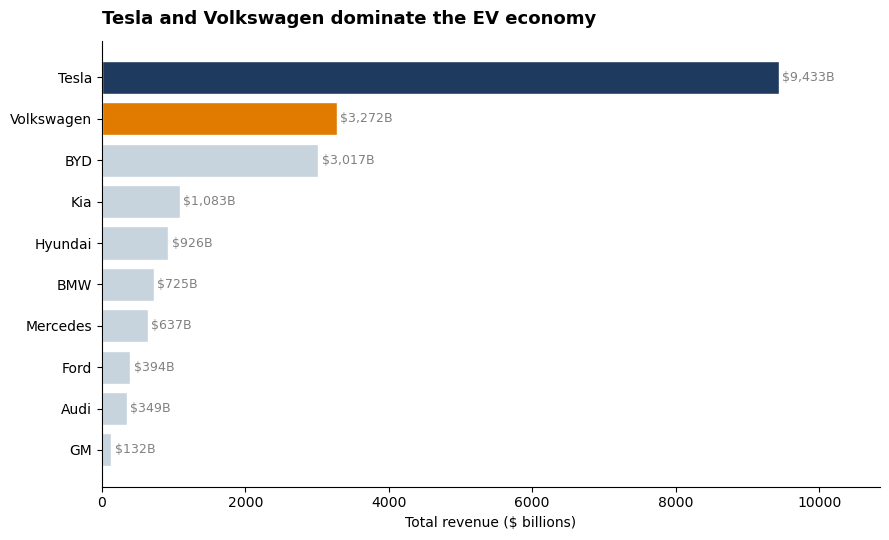

In [50]:
# Calculate total revenue per brand, take the top 10
top_brands = df_ev_market.groupby('brand')['revenue_usd'].sum().sort_values(ascending=True).tail(10)

# colour palette
navy = '#1F3A5F'
orange = '#E07B00'
light_grey = '#C7D3DD'

# Colour the top two bars to draw the eye (Accent and Navy)
colors_figure_3 = [light_grey] * 8 + [orange, navy]

# Build the chart
figure_3, ax_3 = plt.subplots(figsize=(9, 5.5))
ax_3.barh(top_brands.index, top_brands.values / 1e9, color=colors_figure_3, edgecolor='white')
ax_3.set_title('Tesla and Volkswagen dominate the EV economy', loc='left', fontsize=13, fontweight='bold', pad=12)
ax_3.set_xlabel('Total revenue ($ billions)', fontsize=10)
ax_3.spines['top'].set_visible(False)        # to delete top border of the chart
ax_3.spines['right'].set_visible(False)      # to hide right border of the chart
ax_3.set_xlim(0, top_brands.max() / 1e9 * 1.15)

# Add data labels at the end of each bar
for i, value in enumerate(top_brands.values):
    ax_3.text(value / 1e9 + 50, i, f'${value/1e9:,.0f}B', va='center', fontsize=9, color='grey')

plt.tight_layout()
plt.show()

**What it shows:** Tesla generates roughly 3x the revenue of the next competitor (Volkswagen). The cliff after the top three brands is striking. There is no broad middle tier, just a small group of giants and a long tail.

### Chart 2 — Horsepower vs Price, coloured by market segment

A scatter plot reveals what a single correlation coefficient hides: the *shape* of the relationship. Colouring by segment shows whether the price-power link is uniform or segment-specific.


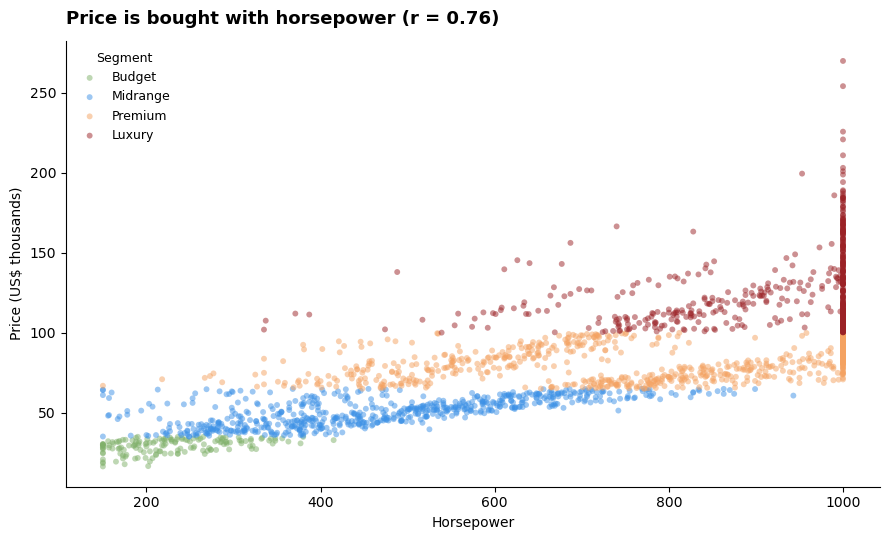

In [51]:
# Build the scatter — loop through segments to assign colours
figure_4, ax_4 = plt.subplots(figsize=(9, 5.5))

colors_figure_4 = {
    'Budget': '#7FB069',
    'Midrange': '#3C91E6',
    'Premium': '#F4A261',
    'Luxury': '#9B2226'
}

for segment, color in colors_figure_4.items():
    subset = df_ev_market[df_ev_market['market_segment'] == segment]
    ax_4.scatter(subset['horsepower'], subset['price_usd'] / 1000, c=color, alpha=0.5, s=18, label=segment, edgecolor='none')

# Calculate and display the correlation
corr_value_horsepower_price = df_ev_market['horsepower'].corr(df_ev_market['price_usd'])

ax_4.set_title(f'Price is bought with horsepower (r = {corr_value_horsepower_price:.2f})', loc='left', fontsize=13, fontweight='bold', pad=12)
ax_4.set_xlabel('Horsepower', fontsize=10)
ax_4.set_ylabel('Price (US$ thousands)', fontsize=10)
ax_4.legend(loc='upper left', frameon=False, fontsize=9, title='Segment', title_fontsize=9)
ax_4.spines['top'].set_visible(False)        
ax_4.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**What it shows:** The four segments stack into clean horizontal bands. Within any given horsepower level, segment determines price by roughly $10k–70k steps. The vertical wall at horsepower = 1000 is a data artefact, as the dataset caps horsepower at 1000, which so many high-end cars pile up at that exact value.

For example:
At hp ≈ 350 :
- Budget     -> around `$40k`   
- Midrange   -> around `$50k`   
- Premium    -> around `$75k`   
- Luxury     -> around `$110k`  

### Chart 3 — Correlation heatmap

A heatmap is far more readable than a correlation table for spotting which variables drive which. The full correlation matrix is computed first, then visualised.


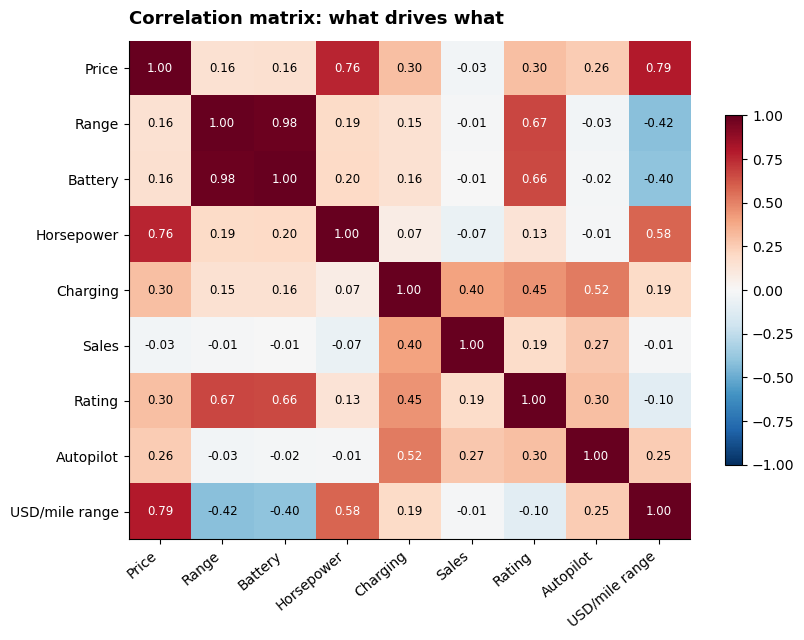

In [52]:
# List of key numeric columns for the heatmap
key_cols = ['price_usd', 'range_miles', 'battery_capacity_kwh', 'horsepower',
            'charging_speed_kw', 'annual_sales_units', 'customer_rating',
            'autopilot_level', 'usd_per_mile_range']

corr_matrix = df_ev_market[key_cols].corr()

# Build the heatmap
figure_5, ax_5 = plt.subplots(figsize=(8.5, 6.5))
corr_heatmap = ax_5.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Short labels for readability
corr_labels = ['Price', 'Range', 'Battery', 'Horsepower', 'Charging', 'Sales', 'Rating', 'Autopilot', 'USD/mile range']
ax_5.set_xticks(range(len(key_cols)))
ax_5.set_yticks(range(len(key_cols)))
ax_5.set_xticklabels(corr_labels, rotation=40, ha='right')
ax_5.set_yticklabels(corr_labels)

# Annotate each cell with its correlation value
for i in range(len(key_cols)):
    for j in range(len(key_cols)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            text_color_figure_5 = 'white'
        else:
            text_color_figure_5 = 'black'
        ax_5.text(j, i, f'{corr_value:.2f}', ha='center', va='center', color=text_color_figure_5, fontsize=8.5)

ax_5.set_title('Correlation matrix: what drives what', loc='left', fontsize=13, fontweight='bold', pad=12)
plt.colorbar(corr_heatmap, ax=ax_5, shrink=0.7) # bar legend
ax_5.spines['top'].set_visible(False)        
ax_5.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**What it shows:**

- **Price <-> Horsepower (0.76)** — the strongest non-trivial correlation. Performance, not range, drives price.
- **Rating <-> Range (0.67) and Rating <-> Battery (0.66)** — what customers reward is range, not price.
- **Sales row is mostly white** — annual sales correlate near-zero with price (-0.03) and range (-0.01). The strongest sales correlate is charging speed (0.40).
- **Range <-> Battery (0.98)** — these are almost the same signal.

### Chart 4 — Value-for-money by country of origin

This is the headline geographic finding. Calculating `usd_per_mile_range` averaged by country exposes a structural cost gap between regions.


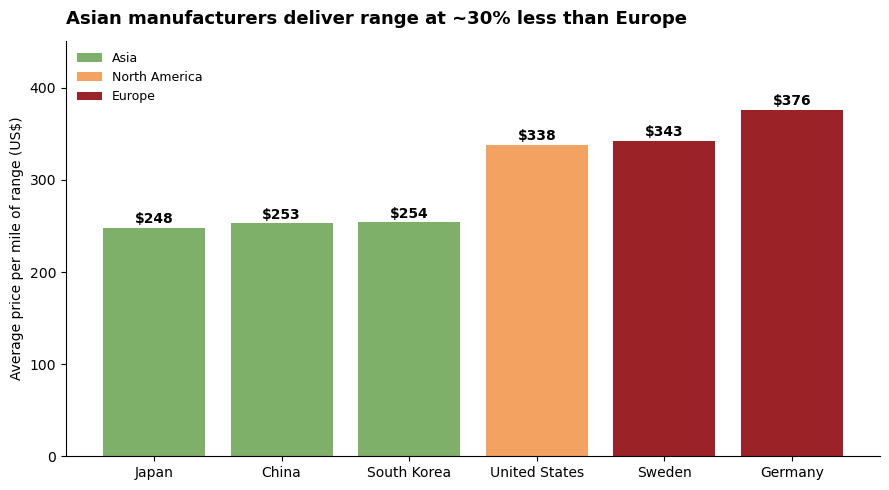

In [53]:
# Calculate average $/mile by country, sort ascending
country_value = df_ev_market.groupby('country_of_origin')['usd_per_mile_range'].mean().sort_values()

# Group countries into regions for colour-coding
def region_for(country):
    if country in ['Japan', 'China', 'South Korea']:
        return 'Asia'
    elif country in ['United States']:
        return 'North America'
    elif country in ['Germany', 'Sweden']:
        return 'Europe'

region_colors = {'Asia': '#7FB069', 'North America': '#F4A261', 'Europe': '#9B2226'}
colors_figure_6 = [region_colors[region_for(c)] for c in country_value.index]

# Build the chart
figure_6, ax_6 = plt.subplots(figsize=(9, 5))

bars_6 = ax_6.bar(country_value.index, country_value.values, color=colors_figure_6)

# Add value labels above each bar
for bar, value in zip(bars_6, country_value.values):
    ax_6.text(bar.get_x() + bar.get_width()/2, value + 5, f'${value:.0f}', ha='center', fontsize=10, fontweight='bold')

# Custom legend using matplotlib.patches
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color, label=region) for region, color in region_colors.items()]
ax_6.legend(handles=legend_handles, loc='upper left', frameon=False, fontsize=9, title_fontsize=9)

ax_6.set_title('Asian manufacturers deliver range at ~30% less than Europe', loc='left', fontsize=13, fontweight='bold', pad=12)
ax_6.set_ylabel('Average price per mile of range (US$)', fontsize=10)
ax_6.spines['top'].set_visible(False)        
ax_6.spines['right'].set_visible(False)
ax_6.set_ylim(0, country_value.max() * 1.2)

plt.tight_layout()
plt.show()

**What it shows:** Three Asian countries cluster at approx. USD 250/mile. The United States sits 35% higher at USD 338/mile. The two European countries are at USD 343/mile and USD 376/mile, which roughly 50% more than the Asian benchmark. This is a structural cost-efficiency gap, not a discounting or marketing issue.

### Chart 5 — Strategic quadrant (bubble chart)

Plotting average sales (volume) against average price (margin) for every brand, with bubble size for total revenue, reveals where each brand competes and crucially, where nobody competes.


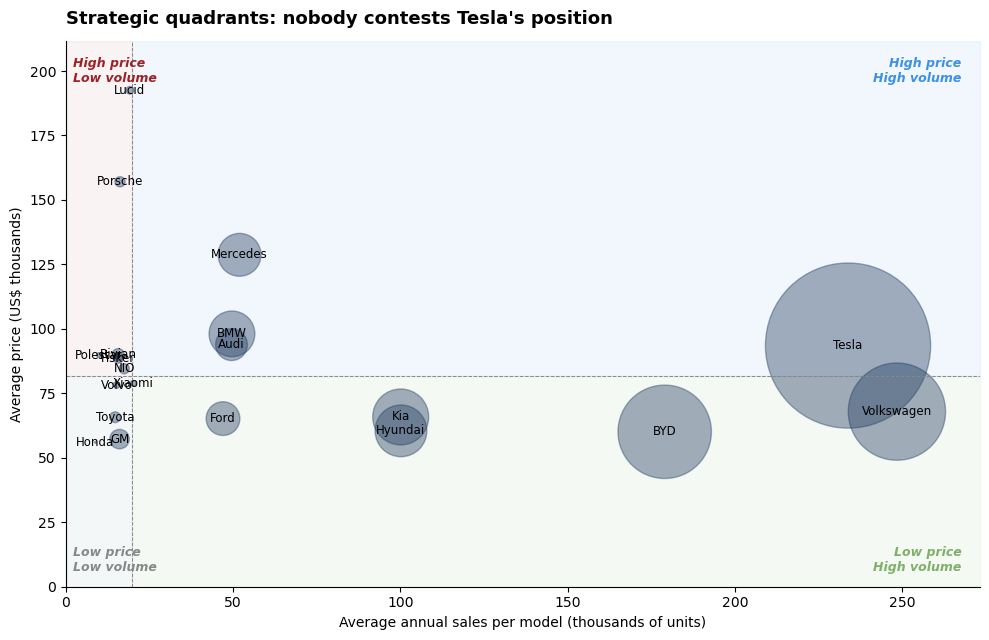

In [54]:
# Build brand-level summary
brand_summary = df_ev_market.groupby('brand').agg(
    avg_price=('price_usd', 'mean'),
    avg_sales=('annual_sales_units', 'mean'),
    total_revenue=('revenue_usd', 'sum')
).reset_index()

# Scale to readable units (USD thousands)
brand_summary['avg_sales_k'] = brand_summary['avg_sales'] / 1000
brand_summary['avg_price_k'] = brand_summary['avg_price'] / 1000
brand_summary['bubble_size'] = brand_summary['total_revenue'] / 1e10 * 15    # 15 is the multiplier to adjust the size of the bubble

# Median lines split the chart into four quadrants
median_sales = brand_summary['avg_sales_k'].median()
median_price = brand_summary['avg_price_k'].median()

# Build the chart
figure_7, ax_7 = plt.subplots(figsize=(10, 6.5))

# Quadrant background shading (setting the alpha for shading)
x_max_quadrant = brand_summary['avg_sales_k'].max() * 1.1
y_max_quadrant = brand_summary['avg_price_k'].max() * 1.1
ax_7.fill_between([0, median_sales], median_price, y_max_quadrant, color='#9B2226', alpha=0.05)                # top-left quadrant
ax_7.fill_between([median_sales, x_max_quadrant], median_price, y_max_quadrant, color='#3C91E6', alpha=0.07)   # top-right quadrant
ax_7.fill_between([0, median_sales], 0, median_price, color=light_grey, alpha=0.18)                            # bottom-left quadrant
ax_7.fill_between([median_sales, x_max_quadrant], 0, median_price, color='#7FB069', alpha=0.07)                # bottom-right quadrant

# Median lines
ax_7.axhline(median_price, color='#888', lw=0.7, linestyle='--')
ax_7.axvline(median_sales, color='#888', lw=0.7, linestyle='--')

# Bubbles
ax_7.scatter(brand_summary['avg_sales_k'], brand_summary['avg_price_k'], s=brand_summary['bubble_size'], c=navy, alpha=0.4, edgecolor=navy)

# Brand labels
for _, row in brand_summary.iterrows(): # we only need the row in brand_summary, we throw away the index (therefore there is _)
    ax_7.annotate(row['brand'], (row['avg_sales_k'], row['avg_price_k']), fontsize=8.5, ha='center', va='center')

# Quadrant labels in corners
ax_7.text(x_max_quadrant*0.98, y_max_quadrant*0.97, 'High price\nHigh volume', ha='right', va='top', fontsize=9, color='#3C91E6', style='italic', fontweight='bold')
ax_7.text(2, y_max_quadrant*0.97, 'High price\nLow volume', ha='left', va='top', fontsize=9, color='#9B2226', style='italic', fontweight='bold')
ax_7.text(x_max_quadrant*0.98, 5, 'Low price\nHigh volume', ha='right', va='bottom', fontsize=9, color='#7FB069', style='italic', fontweight='bold')
ax_7.text(2, 5, 'Low price\nLow volume', ha='left', va='bottom', fontsize=9, color='#888', style='italic', fontweight='bold')


ax_7.set_title("Strategic quadrants: nobody contests Tesla's position", loc='left', fontsize=13, fontweight='bold', pad=12)
ax_7.set_xlabel('Average annual sales per model (thousands of units)', fontsize=10)
ax_7.set_ylabel('Average price (US$ thousands)', fontsize=10)
ax_7.spines['top'].set_visible(False)        
ax_7.spines['right'].set_visible(False)
ax_7.set_xlim(0, x_max_quadrant)
ax_7.set_ylim(0, y_max_quadrant)

plt.tight_layout()
plt.show()

**What it shows:** Tesla sits alone in the top-right quadrant — high price, high volume. No other brand competes for that position. Volkswagen and BYD dominate the volume-king quadrant (bottom-right). Lucid, Porsche, and Mercedes run margin-specialist plays in the top-left. The empty space around Tesla is the most defensible competitive position in the dataset.

### Chart 6 — Customer rating vs Range

A scatter plot with an overlaid binned average line shows both the raw scatter and the clean underlying trend. This makes the r = 0.67 correlation visible as a near-linear ascending relationship.


In [1]:
# Bin range_miles into 12 equal bins, calculate mean rating per bin (to create markers in average line plot)
df_ev_market['temp_range_bin'] = pd.cut(df_ev_market['range_miles'], bins=15)
binned_means = df_ev_market.groupby('temp_range_bin', observed=True, as_index=False).agg(
    bin_mid=('range_miles', 'mean'),
    mean_rating=('customer_rating', 'mean')
)

# Build the chart
figure_8, ax_8 = plt.subplots(figsize=(9, 5.5))

# Underlying scatter
ax_8.scatter(df_ev_market['range_miles'], df_ev_market['customer_rating'], alpha=0.25, s=15, c=navy, edgecolor='none')

# Overlaid binned average line
ax_8.plot(binned_means['bin_mid'], binned_means['mean_rating'], color=orange, lw=2.5, marker='o', markersize=7, label='Binned average')

corr_value_range_rating = df_ev_market['range_miles'].corr(df_ev_market['customer_rating'])

ax_8.set_title(f'Customers reward range — the strongest driver of satisfaction (r = {corr_value_range_rating:.2f})', loc='left', fontsize=13, fontweight='bold', pad=12)
ax_8.set_xlabel('Range (miles)', fontsize=10)
ax_8.set_ylabel('Customer rating', fontsize=10)
ax_8.spines['top'].set_visible(False)        
ax_8.spines['right'].set_visible(False)
ax_8.legend(loc='lower right', frameon=False, fontsize=9)
ax_8.set_ylim(2.8, 5.1)

plt.tight_layout()
plt.show()

# Drop the temporary binning column to keep the dataframe clean
df_ev_market = df_ev_market.drop(columns=['temp_range_bin'])

NameError: name 'pd' is not defined

**What it shows:** The orange line rises almost perfectly monotonically from 3.3 (at ~150 miles of range) to 4.0 (at ~430 miles). Range is the cleanest predictor of customer satisfaction in the dataset.

## 5. Analytical Findings

 ### 5.1 Grouped analysis — segment economics

In [56]:
# Aggregate every key metric by market segment
segment_economics = df_ev_market.groupby('market_segment').agg(
    n_models=('model', 'count'),
    avg_price=('price_usd', 'mean'),
    avg_range=('range_miles', 'mean'),
    avg_charging_kw=('charging_speed_kw', 'mean'),
    avg_rating=('customer_rating', 'mean'),
    total_revenue=('revenue_usd', 'sum'),
    avg_usd_per_mile=('usd_per_mile_range', 'mean')
).round(1)

segment_economics

,n_models,avg_price,avg_range,avg_charging_kw,avg_rating,total_revenue,avg_usd_per_mile
market_segment,,,,,,,
Budget,151,"29,320.80",236.10,127.70,3.50,"671,737,721,015.10",132.50
Luxury,495,"127,340.00",275.30,195.70,3.70,"8,335,161,063,345.20",496.80
Midrange,642,"50,688.80",255.10,140.40,3.50,"4,155,386,796,065.90",215.50
Premium,712,"81,102.30",263.90,146.30,3.50,"7,062,643,029,163.60",330.00


**Reading the segment table:**

- **Budget** segment averages USD 29k+ price, 236 miles of range with rating of 3.5 that matches other segments, suggesting buyers are satisfied despite low price point
- **Luxury** segment averages USD 127k+ and leads total revenue at USD 8.3 trillion. The rating also gains over the other segments is marginal (3.7 vs. 3.5), suggesting diminishing return at the top (rating improvement gets smaller, no big difference).
- **Total revenue** is largest in Luxury (8.3T) followed closely by Premium (7.1T). It means the high end of the market dominates commercially despite having fewer models than Midrange and Premium combined.

### 5.2 Correlation analysis — the full picture

In [57]:
corr_matrix  # from chart 3 — Correlation matrix heatmap

,price_usd,range_miles,battery_capacity_kwh,horsepower,charging_speed_kw,annual_sales_units,customer_rating,autopilot_level,usd_per_mile_range
price_usd,1.00,0.16,0.16,0.76,0.30,-0.03,0.30,0.26,0.79
range_miles,0.16,1.00,0.98,0.19,0.15,-0.01,0.67,-0.03,-0.42
battery_capacity_kwh,0.16,0.98,1.00,0.20,0.16,-0.01,0.66,-0.02,-0.40
horsepower,0.76,0.19,0.20,1.00,0.07,-0.07,0.13,-0.01,0.58
charging_speed_kw,0.30,0.15,0.16,0.07,1.00,0.40,0.45,0.52,0.19
annual_sales_units,-0.03,-0.01,-0.01,-0.07,0.40,1.00,0.19,0.27,-0.01
customer_rating,0.30,0.67,0.66,0.13,0.45,0.19,1.00,0.30,-0.10
autopilot_level,0.26,-0.03,-0.02,-0.01,0.52,0.27,0.30,1.00,0.25
usd_per_mile_range,0.79,-0.42,-0.40,0.58,0.19,-0.01,-0.10,0.25,1.00


In [58]:
# Sort to find what most strongly correlates with each commercial outcome
print("=== Strongest correlations with PRICE ===")
print(corr_matrix['price_usd'].drop('price_usd').sort_values(ascending=False).head(5))
print()
print("=== Strongest correlations with CUSTOMER RATING ===")
print(corr_matrix['customer_rating'].drop('customer_rating').sort_values(ascending=False).head(5))
print()
print("=== Strongest correlations with ANNUAL SALES ===")
print(corr_matrix['annual_sales_units'].drop('annual_sales_units').sort_values(ascending=False).head(5))

=== Strongest correlations with PRICE ===
usd_per_mile_range   0.79
horsepower           0.76
charging_speed_kw    0.30
customer_rating      0.30
autopilot_level      0.26
Name: price_usd, dtype: float64

=== Strongest correlations with CUSTOMER RATING ===
range_miles            0.67
battery_capacity_kwh   0.66
charging_speed_kw      0.45
autopilot_level        0.30
price_usd              0.30
Name: customer_rating, dtype: float64

=== Strongest correlations with ANNUAL SALES ===
charging_speed_kw       0.40
autopilot_level         0.27
customer_rating         0.19
battery_capacity_kwh   -0.01
usd_per_mile_range     -0.01
Name: annual_sales_units, dtype: float64


**The three correlation rankings tell the central story of this dataset:**

- **Price** is driven by USD/mile range (0.79) and horsepower (0.76) -> performance and efficiency, not range, is what manufacturers monetise.
- **Customer rating** is driven by range (0.67) and battery (0.66) -> buyers reward useful capability (long range).
- **Sales volume** is driven by charging speed (0.40) -> fast charging is the gating commercial variable.

These three drivers are *different*:
1. Manufacturers are optimising for power
2. Customers want range
3. The market rewards charging infrastructure compatibility

This shows a **genuine strategic misalignment in the EV market**. The manufacturers are investing in the wrong things relative to what actually sells and what customers actually value.

### 5.3 Do wealthier countries produce worse-value EV?

To test whether the country-level value gap (Asian EVs cheaper per mile than European) reflects structural economic factors, we merge with a small reference dataset of country-level economic indicators. The reference data is sourced from publicly available figures (World Bank GDP per capita 2025 estimates and International Energy Agency (IEA) EV sales share 2025).

In [59]:
# Build the reference dataset as a small DataFrame
country_reference = pd.DataFrame({
    'country_of_origin': ['United States', 'Germany', 'Japan', 'South Korea', 'China', 'Sweden'],
    'gdp_per_capita_usd': [66683, 44109, 37145, 36239, 13122, 54916],
    'ev_sales_share_pct': [10.0, 30.0, 2.0, 11.0, 55.0, 60.0]
})
# Source: Trading Economics (n.d.a-f); IEA (2026)

print("Reference dataset:")
country_reference

Reference dataset:


,country_of_origin,gdp_per_capita_usd,ev_sales_share_pct
0,United States,66683,10.00
1,Germany,44109,30.00
2,Japan,37145,2.00
3,South Korea,36239,11.00
4,China,13122,55.00
5,Sweden,54916,60.00


In [60]:
# Merge using pd.merge — left join keeps every row in the EV dataset
df_ev_market_merged = pd.merge(df_ev_market, country_reference, on='country_of_origin', how='left')

# Confirm the merge succeeded — no nulls in new columns
print(f"Merged shape: {df_ev_market_merged.shape}")
print(f"Nulls in new columns: {df_ev_market_merged[['gdp_per_capita_usd', 'ev_sales_share_pct']].isnull().sum().sum()}")
df_ev_market_merged[['brand', 'country_of_origin', 'price_usd', 'usd_per_mile_range', 'gdp_per_capita_usd', 'ev_sales_share_pct']].head()

Merged shape: (2000, 30)
Nulls in new columns: 0


,brand,country_of_origin,price_usd,usd_per_mile_range,gdp_per_capita_usd,ev_sales_share_pct
0,Volkswagen,Germany,"104,880.80",262.20,44109,30.00
1,Toyota,Japan,"48,217.41",220.17,37145,2.00
2,GM,United States,"49,651.12",220.67,66683,10.00
3,Kia,South Korea,"38,131.56",109.26,36239,11.00
4,Tesla,United States,"144,079.87",458.85,66683,10.00


In [61]:
country_summary = (df_ev_market_merged.groupby('country_of_origin').agg(
    avg_usd_per_mile=('usd_per_mile_range', 'mean'),
    gdp_per_capita=('gdp_per_capita_usd', 'mean'),
    ev_sales_share=('ev_sales_share_pct', 'mean'))
).round(2)

print("Correlation between $/mile of range and macro variables:")
print(country_summary.corr()['avg_usd_per_mile'].sort_values(ascending=False))
print()
country_summary.sort_values('avg_usd_per_mile')

Correlation between $/mile of range and macro variables:
avg_usd_per_mile   1.00
gdp_per_capita     0.68
ev_sales_share     0.24
Name: avg_usd_per_mile, dtype: float64



,avg_usd_per_mile,gdp_per_capita,ev_sales_share
country_of_origin,,,
Japan,248.19,"37,145.00",2.00
China,252.84,"13,122.00",55.00
South Korea,253.87,"36,239.00",11.00
United States,338.24,"66,683.00",10.00
Sweden,342.59,"54,916.00",60.00
Germany,376.06,"44,109.00",30.00


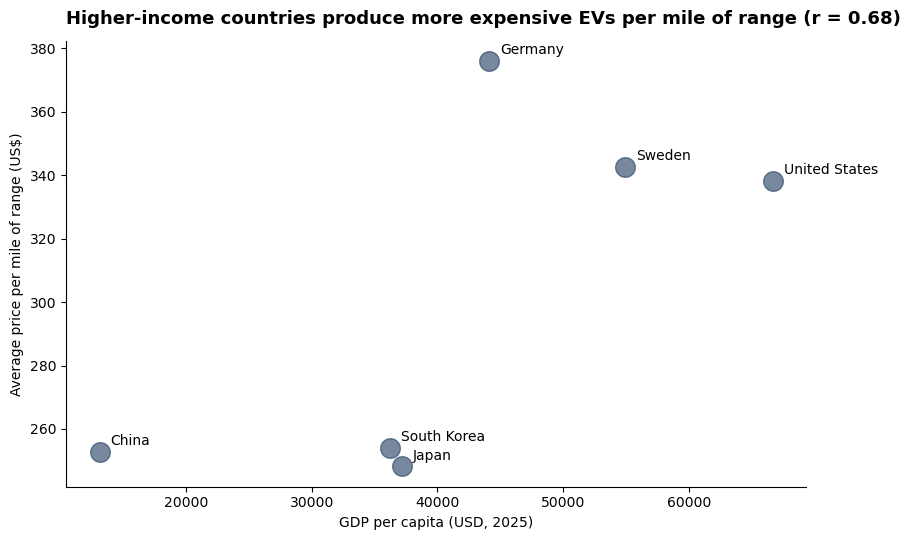

In [62]:
figure_9, ax_9 = plt.subplots(figsize=(9, 5.5))

ax_9.scatter(country_summary['gdp_per_capita'], country_summary['avg_usd_per_mile'], s=200, c=navy, alpha=0.6, edgecolor=navy)

for country, row in country_summary.iterrows():
    ax_9.annotate(country, (row['gdp_per_capita'], row['avg_usd_per_mile']), xytext=(8, 5), textcoords='offset points', fontsize=10)

ax_9.set_title(f'Higher-income countries produce more expensive EVs per mile of range (r = {country_summary['gdp_per_capita'].corr(country_summary['avg_usd_per_mile']):.2f})', loc='left', fontsize=13, fontweight='bold', pad=12)
ax_9.set_xlabel('GDP per capita (USD, 2025)', fontsize=10)
ax_9.set_ylabel('Average price per mile of range (US$)', fontsize=10)
ax_9.spines['top'].set_visible(False)        
ax_9.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Asian manufacturers deliver ~30% better $/mile-of-range** than European ones. The merged analysis shows this correlates with GDP per capita (r = ~0.68). It means richer countries produce more expensive EVs relative to their range.

### Summary

In [63]:
print("1. WHAT DRIVES PRICE?")
print(f"   Horsepower is the strongest driver (r = {df_ev_market['horsepower'].corr(df_ev_market['price_usd']):.2f})")
print(f"   Range barely correlates with price (r = {df_ev_market['range_miles'].corr(df_ev_market['price_usd']):.2f})")
print("   -> Manufacturers price on performance, not range.")

print("\n2. WHAT DRIVES CUSTOMER SATISFACTION?")
print(f"   Range correlates with rating (r = {df_ev_market['range_miles'].corr(df_ev_market['customer_rating']):.2f})")
print(f"   Battery capacity correlates with rating (r = {df_ev_market['battery_capacity_kwh'].corr(df_ev_market['customer_rating']):.2f})")
print("   -> Customers reward useful capability, not price or power.")

print("\n3. WHAT DRIVES SALES VOLUME?")
print(f"   Charging speed is the strongest driver (r = {df_ev_market['charging_speed_kw'].corr(df_ev_market['annual_sales_units']):.2f})")
print(f"   Price has almost no effect on sales (r = {df_ev_market['price_usd'].corr(df_ev_market['annual_sales_units']):.2f})")
print("   -> Fast charging compatibility is the gating commercial variable.")

print("\n4. GEOGRAPHIC VALUE GAP")
for country, val in country_value.items():
    print(f"   {country:<15} ${val:.0f} per mile of range")
print("   -> Asian manufacturers deliver significantly better value than European ones.")

print("\n5. CENTRAL FINDING")
print("   The three key drivers point in different directions:")
print("   - Manufacturers optimise for POWER")
print("   - Customers value RANGE")
print("   - The market rewards CHARGING SPEED")
print("   -> Strategic misalignment. Tesla is the only brand occupying the high-price, high-volume quadrant.")

1. WHAT DRIVES PRICE?
   Horsepower is the strongest driver (r = 0.76)
   Range barely correlates with price (r = 0.16)
   -> Manufacturers price on performance, not range.

2. WHAT DRIVES CUSTOMER SATISFACTION?
   Range correlates with rating (r = 0.67)
   Battery capacity correlates with rating (r = 0.66)
   -> Customers reward useful capability, not price or power.

3. WHAT DRIVES SALES VOLUME?
   Charging speed is the strongest driver (r = 0.40)
   Price has almost no effect on sales (r = -0.03)
   -> Fast charging compatibility is the gating commercial variable.

4. GEOGRAPHIC VALUE GAP
   Japan           $248 per mile of range
   China           $253 per mile of range
   South Korea     $254 per mile of range
   United States   $338 per mile of range
   Sweden          $343 per mile of range
   Germany         $376 per mile of range
   -> Asian manufacturers deliver significantly better value than European ones.

5. CENTRAL FINDING
   The three key drivers point in different dire

### References
- International Energy Agency [IEA]. (2026). *Global EV outlook 2026*. https://www.iea.org/reports/global-ev-outlook-2026
- Patel, R. (2026). *Electric vehicle market and pricing dataset 2026 [Data set]*. Kaggle. https://www.kaggle.com/datasets/patelris/electric-vehicle-market-and-pricing-dataset-2026
- Trading Economics. (n.d.a). *United States GDP per capita PPP*. https://tradingeconomics.com/united-states/gdp-per-capita-ppp
- Trading Economics. (n.d.b). *Germany GDP per capita*. https://tradingeconomics.com/germany/gdp-per-capita
- Trading Economics. (n.d.c). *Japan GDP per capita*. https://tradingeconomics.com/japan/gdp-per-capita
- Trading Economics. (n.d.d). *South Korea GDP per capita*. https://tradingeconomics.com/south-korea/gdp-per-capita
- Trading Economics. (n.d.e). *China GDP per capita*. https://tradingeconomics.com/china/gdp-per-capita
- Trading Economics. (n.d.f). *Sweden GDP per capita*. https://tradingeconomics.com/sweden/gdp-per-capita
